# 09. 외부 검증 — 역사적 침수 기록 & CCI 정합성 분석
## Historical Flood Trace Validation

**목적**: 실제 침수 발생 이력(2017-2020)과 CCI 고위험 지역이 일치하는지 검증합니다.

**데이터 한계**: 2022년 폭우(8월 8일) 실측 피해 데이터는 미확보 상태입니다.  
대신 2017-2020년 서울시 침수흔적도 shapefile을 활용하여 **역사적 침수 취약성 ↔ CCI** 정합성을 검증합니다.

| 검증 항목 | 방법 |
|-----------|------|
| 침수 취약성 ↔ CCI/RII 상관 | 동별 역사 침수 면적과 CCI·RII의 Spearman 상관 |
| triple_high 동의 침수 이력 | triple_high 11개 동 과거 침수 기록 포함 여부 |
| 상위 10% 고위험 동의 침수 비율 | CCI 상위 42개 동 중 침수 기록 있는 비율 vs 하위 동 |
| LISA HH 핫스팟 침수 프리미엄 | HH vs LL 동의 평균 침수 면적 비교 |

---
## 1. 설정 및 데이터 로드

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
from scipy.stats import spearmanr, mannwhitneyu
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

rcParams['font.family'] = 'Malgun Gothic'
rcParams['axes.unicode_minus'] = False

BASE_DIR = Path('c:/Tsum2026/T_SUM2026')
RAW_DIR  = BASE_DIR / 'data' / 'raw' / 'RII_rain_flood'
OUT_DIR  = BASE_DIR / 'data' / 'output'
FIG_DIR  = BASE_DIR / 'outputs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# CCI GeoPackage
gdf = gpd.read_file(OUT_DIR / 'final_crisis_index_by_dong_2021.gpkg')
gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].reset_index(drop=True)
if gdf.crs.to_epsg() != 5179:
    gdf = gdf.to_crs(epsg=5179)
print(f'CCI 행정동: {len(gdf)}개')

# flood_trace 2017-2020 합치기
flood_all = []
for yr in [2017, 2018, 2019, 2020]:
    path = RAW_DIR / 'flood_trace' / str(yr) / f'서울시_{yr}.shp'
    ft = gpd.read_file(str(path))
    ft['flood_year'] = yr
    flood_all.append(ft)
flood = gpd.GeoDataFrame(pd.concat(flood_all, ignore_index=True), crs='EPSG:5179')
flood = flood[flood.geometry.notna() & ~flood.geometry.is_empty].reset_index(drop=True)
print(f'침수흔적 폴리곤 총합: {len(flood)}개 (2017-2020)')
print(f'연도별 분포: {flood["flood_year"].value_counts().to_dict()}')

CCI 행정동: 420개
침수흔적 폴리곤 총합: 1027개 (2017-2020)
연도별 분포: {2018: 842, 2020: 166, 2017: 13, 2019: 6}


---
## 2. 공간 조인 — 침수흔적 ↔ 행정동

In [2]:
# Spatial join: 침수 폴리곤이 어느 행정동에 속하는지
flood_proj = flood.to_crs(epsg=5179) if flood.crs.to_epsg() != 5179 else flood

joined = gpd.sjoin(
    flood_proj[['F_AREA', 'F_SHIM', 'flood_year', 'geometry']],
    gdf[['행정동코드', '자치구명', '행정동명', 'CCI', 'RII', 'CCI_rank', 'triple_high_flag', 'geometry']],
    how='left',
    predicate='intersects'
)

print(f'매칭된 침수 폴리곤: {joined["행정동명"].notna().sum()}/{len(joined)}')

# 행정동별 침수 집계
flood_by_dong = joined.groupby('행정동코드').agg(
    flood_count=('F_AREA', 'count'),
    flood_area_sum=('F_AREA', 'sum'),
    flood_depth_mean=('F_SHIM', 'mean'),
    flood_years=('flood_year', lambda x: x.nunique()),
).reset_index()

print(f'침수 이력이 있는 행정동: {len(flood_by_dong)}개 / {len(gdf)}개')
print(flood_by_dong.describe().round(2))

매칭된 침수 폴리곤: 1028/1030
침수 이력이 있는 행정동: 121개 / 420개
       flood_count  flood_area_sum  flood_depth_mean  flood_years
count       121.00          121.00            121.00       121.00
mean          8.50         4299.10              0.33         1.20
std          15.07        21797.74              0.14         0.49
min           1.00           10.00              0.05         1.00
25%           1.00          182.20              0.30         1.00
50%           3.00          525.58              0.30         1.00
75%           8.00         1363.37              0.45         1.00
max         109.00       223099.34              0.50         3.00


---
## 3. CCI/RII ↔ 역사적 침수 면적 상관계수

In [3]:
# CCI 데이터에 침수 집계 병합
val_df = gdf[['행정동코드','자치구명','행정동명','IVI','CDI','RII','CCI','CCI_rank','triple_high_flag']].merge(
    flood_by_dong, on='행정동코드', how='left'
)
val_df['flood_count']     = val_df['flood_count'].fillna(0)
val_df['flood_area_sum']  = val_df['flood_area_sum'].fillna(0)
val_df['flood_depth_mean']= val_df['flood_depth_mean'].fillna(0)
val_df['flood_years']     = val_df['flood_years'].fillna(0)
val_df['has_flood']       = (val_df['flood_count'] > 0).astype(int)

# Spearman 상관
print('=== Spearman 상관계수: 역사적 침수 면적 vs 지표 ===')
rows = []
for indicator in ['CCI', 'RII', 'IVI', 'CDI']:
    r, p = spearmanr(val_df[indicator], val_df['flood_area_sum'])
    rows.append({'지표': indicator, 'ρ': round(r, 4), 'p-value': round(p, 4),
                 '유의': '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))})
display(pd.DataFrame(rows))

=== Spearman 상관계수: 역사적 침수 면적 vs 지표 ===


,지표,ρ,p-value,유의
0,CCI,0.3671,0.0000,***
1,RII,0.3458,0.0000,***
2,IVI,0.1582,0.0011,**
3,CDI,0.1120,0.0217,*


---
## 4. triple_high 11개 동의 침수 이력

In [4]:
top_df = pd.read_csv(OUT_DIR / 'top_risk_dongs_2021.csv', encoding='utf-8-sig')

tri_val = val_df[val_df['triple_high_flag'] == 1].copy().sort_values('CCI_rank')
print('=== triple_high 동 침수 이력 ===')
display(tri_val[['자치구명','행정동명','CCI','RII','CCI_rank',
                  'flood_count','flood_area_sum','flood_depth_mean','flood_years','has_flood']]
        .round(3).reset_index(drop=True))

print(f'\ntriple_high 중 침수 이력 있는 동: {tri_val["has_flood"].sum()}/{len(tri_val)}개 ({tri_val["has_flood"].mean()*100:.1f}%)')
print(f'전체 행정동 평균 침수 이력 보유율: {val_df["has_flood"].mean()*100:.1f}%')

=== triple_high 동 침수 이력 ===


,자치구명,행정동명,CCI,RII,CCI_rank,flood_count,flood_area_sum,flood_depth_mean,flood_years,has_flood
0,강북구,수유2동,0.624,0.447,4,10.0,2244.56,0.450,1.0,1
1,중랑구,신내2동,0.605,0.524,9,0.0,0.00,0.000,0.0,0
2,도봉구,도봉2동,0.597,0.392,12,5.0,1363.37,0.300,1.0,1
3,은평구,신사2동,0.594,0.505,14,4.0,463.80,0.300,1.0,1
4,관악구,은천동,0.585,0.431,16,0.0,0.00,0.000,0.0,0
5,관악구,보라매동,0.585,0.431,17,0.0,0.00,0.000,0.0,0
6,은평구,녹번동,0.580,0.445,21,6.0,675.00,0.300,1.0,1
7,강서구,방화2동,0.573,0.491,26,6.0,13846.00,0.367,1.0,1
8,은평구,구산동,0.567,0.431,28,4.0,620.20,0.300,1.0,1
9,은평구,역촌동,0.557,0.439,38,15.0,2786.90,0.300,1.0,1



triple_high 중 침수 이력 있는 동: 7/10개 (70.0%)
전체 행정동 평균 침수 이력 보유율: 28.8%


---
## 5. CCI 상위 10% vs 하위 10% 침수 면적 비교 (Mann-Whitney U 검정)

In [5]:
N = len(val_df)
TOP_N = int(N * 0.10)

top_group  = val_df.nsmallest(TOP_N, 'CCI_rank')['flood_area_sum']
bot_group  = val_df.nlargest(TOP_N, 'CCI_rank')['flood_area_sum']

stat, p_val = mannwhitneyu(top_group, bot_group, alternative='greater')

print(f'CCI 상위 {TOP_N}개 동 — 평균 침수면적: {top_group.mean():.2f} m²')
print(f'CCI 하위 {TOP_N}개 동 — 평균 침수면적: {bot_group.mean():.2f} m²')
print(f'\nMann-Whitney U 검정 (one-sided, 상위>하위):')
print(f'  U = {stat:.1f}, p = {p_val:.4f}')
print('  ' + ('유의미한 차이 (p<0.05)' if p_val < 0.05 else '통계적으로 유의하지 않음 (p≥0.05)'))

# 침수 이력 보유 비율
top_rate = val_df.nsmallest(TOP_N, 'CCI_rank')['has_flood'].mean()
bot_rate = val_df.nlargest(TOP_N, 'CCI_rank')['has_flood'].mean()
print(f'\nCCI 상위 {TOP_N}개 동 침수 이력 보유율: {top_rate*100:.1f}%')
print(f'CCI 하위 {TOP_N}개 동 침수 이력 보유율: {bot_rate*100:.1f}%')

CCI 상위 42개 동 — 평균 침수면적: 7231.43 m²
CCI 하위 42개 동 — 평균 침수면적: 32.19 m²

Mann-Whitney U 검정 (one-sided, 상위>하위):
  U = 1440.5, p = 0.0000
  유의미한 차이 (p<0.05)

CCI 상위 42개 동 침수 이력 보유율: 69.0%
CCI 하위 42개 동 침수 이력 보유율: 11.9%


---
## 6. 시각화 — 침수 면적 vs CCI/RII

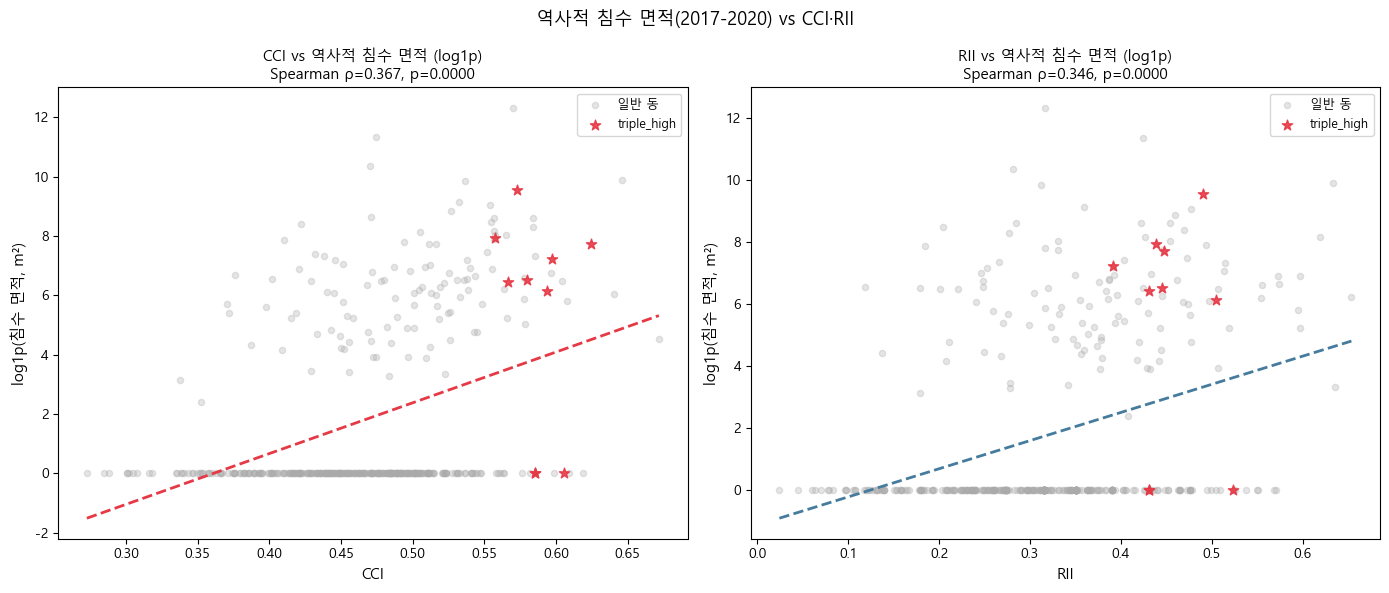

저장: c:\Tsum2026\T_SUM2026\outputs\figures\validation_flood_scatter.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, indicator, color in zip(axes, ['CCI', 'RII'], ['#E63946', '#457B9D']):
    x = val_df[indicator]
    y = np.log1p(val_df['flood_area_sum'])

    is_triple = val_df['triple_high_flag'] == 1
    ax.scatter(x[~is_triple], y[~is_triple], alpha=0.3, s=20, color='#AAAAAA', label='일반 동')
    ax.scatter(x[is_triple],  y[is_triple],  alpha=0.9, s=60, color='#E63946', marker='*', label='triple_high')

    # 추세선
    coef = np.polyfit(x, y, 1)
    xfit = np.linspace(x.min(), x.max(), 100)
    ax.plot(xfit, np.polyval(coef, xfit), color=color, linewidth=2, linestyle='--')

    r, p = spearmanr(x, val_df['flood_area_sum'])
    ax.set_title(f'{indicator} vs 역사적 침수 면적 (log1p)\nSpearman ρ={r:.3f}, p={p:.4f}', fontsize=11)
    ax.set_xlabel(indicator, fontsize=11)
    ax.set_ylabel('log1p(침수 면적, m²)', fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle('역사적 침수 면적(2017-2020) vs CCI·RII', fontsize=13)
plt.tight_layout()
path_scatter = FIG_DIR / 'validation_flood_scatter.png'
plt.savefig(path_scatter, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {path_scatter}')

---
## 7. 구별 침수 밀도 히트맵

=== 구별 침수 이력 & CCI 요약 (상위 15개 구) ===


,자치구명,mean_CCI,mean_RII,total_flood_area,flood_dongs,total_dongs,triple_high_count,flood_rate
0,도봉구,0.534,0.368,256854.45,11,14,1,0.786
1,강동구,0.471,0.336,138732.50,14,16,0,0.875
2,은평구,0.542,0.409,50034.30,14,16,4,0.875
3,강북구,0.586,0.332,19702.36,11,13,1,0.846
4,강서구,0.492,0.388,19302.30,5,18,1,0.278
5,구로구,0.457,0.366,6426.30,3,16,0,0.188
6,노원구,0.444,0.291,6070.77,12,19,0,0.632
7,서대문구,0.466,0.275,5797.86,9,14,0,0.643
8,양천구,0.456,0.333,4987.54,2,18,0,0.111
9,동대문구,0.504,0.402,4590.10,7,14,0,0.500


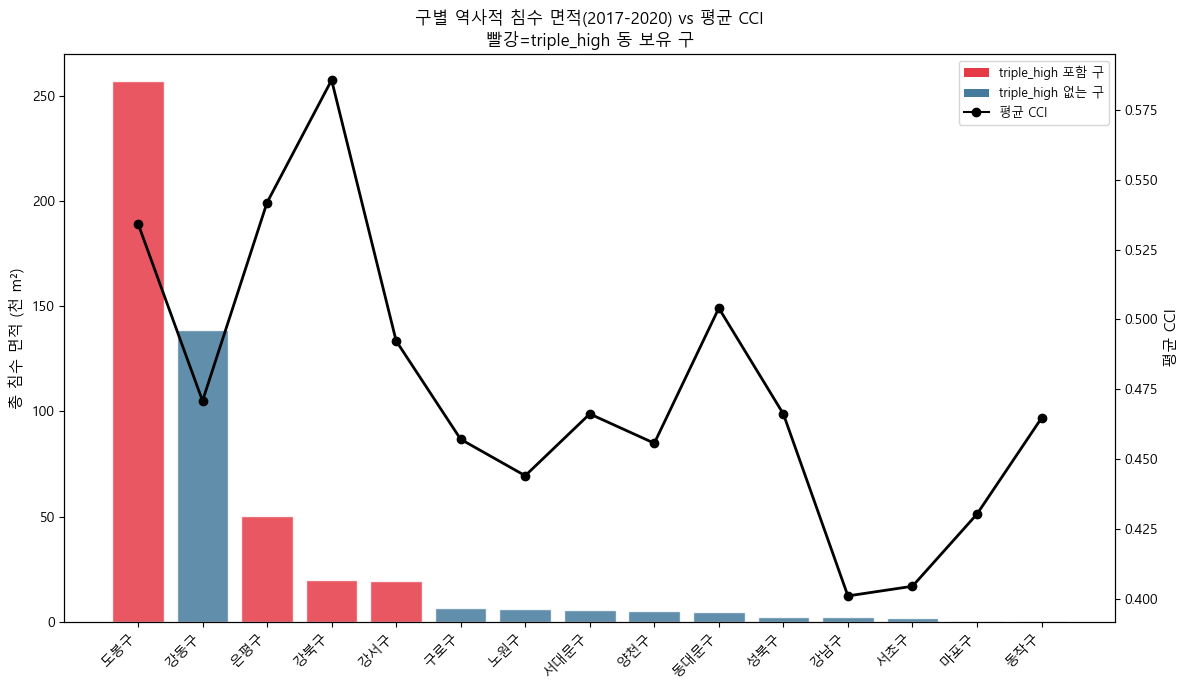

저장: c:\Tsum2026\T_SUM2026\outputs\figures\validation_gu_flood_cci.png


In [7]:
# 구별 집계
gu_summary = val_df.groupby('자치구명').agg(
    mean_CCI=('CCI', 'mean'),
    mean_RII=('RII', 'mean'),
    total_flood_area=('flood_area_sum', 'sum'),
    flood_dongs=('has_flood', 'sum'),
    total_dongs=('has_flood', 'count'),
    triple_high_count=('triple_high_flag', 'sum'),
).reset_index()
gu_summary['flood_rate'] = gu_summary['flood_dongs'] / gu_summary['total_dongs']
gu_summary = gu_summary.sort_values('total_flood_area', ascending=False)

print('=== 구별 침수 이력 & CCI 요약 (상위 15개 구) ===')
display(gu_summary.head(15).round(3).reset_index(drop=True))

# 시각화
fig, ax = plt.subplots(figsize=(12, 7))
top15 = gu_summary.head(15)
bars = ax.bar(range(len(top15)), top15['total_flood_area'] / 1000,
              color=['#E63946' if t > 0 else '#457B9D' for t in top15['triple_high_count']],
              alpha=0.85, edgecolor='white')
ax2 = ax.twinx()
ax2.plot(range(len(top15)), top15['mean_CCI'], 'ko-', linewidth=2, markersize=6, label='평균 CCI')

ax.set_xticks(range(len(top15)))
ax.set_xticklabels(top15['자치구명'], rotation=45, ha='right', fontsize=10)
ax.set_ylabel('총 침수 면적 (천 m²)', fontsize=11)
ax2.set_ylabel('평균 CCI', fontsize=11)
ax.set_title('구별 역사적 침수 면적(2017-2020) vs 평균 CCI\n빨강=triple_high 동 보유 구', fontsize=12)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#E63946', label='triple_high 포함 구'),
                   Patch(facecolor='#457B9D', label='triple_high 없는 구'),
                   plt.Line2D([0],[0], color='black', marker='o', label='평균 CCI')]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
plt.tight_layout()
path_gu = FIG_DIR / 'validation_gu_flood_cci.png'
plt.savefig(path_gu, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {path_gu}')

---
## 8. 2022년 서울 폭우 맥락 — CCI 고위험 지역 검토

In [8]:
# 2022년 8월 8일 폭우 공식 피해 보고 기준 주요 피해 자치구 (출처: 서울시 재난안전대책본부)
# 관악구 · 동작구 · 서초구 · 강남구 집중 피해
known_2022_hit = ['관악구', '동작구', '서초구', '강남구', '중랑구', '강서구', '은평구']

print('=== 2022년 폭우 주요 피해 구 — CCI 현황 ===')
for gu in known_2022_hit:
    sub = val_df[val_df['자치구명'] == gu]
    tri = sub[sub['triple_high_flag'] == 1]
    print(f'  {gu:6s} | 평균CCI={sub["CCI"].mean():.3f} | 행정동수={len(sub)} '
          f'| triple_high={len(tri)}개 '
          f'| 침수이력={sub["has_flood"].sum()}개 동')
print()

# CCI 상위 20위 — 2022년 피해 구 포함 여부
top20 = val_df.nsmallest(20, 'CCI_rank')[['자치구명','행정동명','CCI','CCI_rank','RII','triple_high_flag']]
top20['2022_피해구'] = top20['자치구명'].isin(known_2022_hit)
print('=== CCI 상위 20개 동 중 2022 피해 구 포함 비율 ===')
print(f'  상위 20개 중 {top20["2022_피해구"].sum()}개 동이 2022년 폭우 피해 구에 속함 '
      f'({top20["2022_피해구"].mean()*100:.1f}%)')
display(top20.reset_index(drop=True))

=== 2022년 폭우 주요 피해 구 — CCI 현황 ===
  관악구    | 평균CCI=0.509 | 행정동수=21 | triple_high=2개 | 침수이력=0개 동
  동작구    | 평균CCI=0.465 | 행정동수=15 | triple_high=0개 | 침수이력=2개 동
  서초구    | 평균CCI=0.405 | 행정동수=18 | triple_high=0개 | 침수이력=3개 동
  강남구    | 평균CCI=0.401 | 행정동수=21 | triple_high=0개 | 침수이력=7개 동
  중랑구    | 평균CCI=0.509 | 행정동수=16 | triple_high=1개 | 침수이력=0개 동
  강서구    | 평균CCI=0.492 | 행정동수=18 | triple_high=1개 | 침수이력=5개 동
  은평구    | 평균CCI=0.542 | 행정동수=16 | triple_high=4개 | 침수이력=14개 동

=== CCI 상위 20개 동 중 2022 피해 구 포함 비율 ===
  상위 20개 중 8개 동이 2022년 폭우 피해 구에 속함 (40.0%)


,자치구명,행정동명,CCI,CCI_rank,RII,triple_high_flag,2022_피해구
0,강북구,번2동,0.671819,1,0.359507,0,False
1,은평구,응암3동,0.646154,2,0.633466,0,True
2,강북구,송천동,0.640511,3,0.468922,0,False
3,강북구,수유2동,0.624484,4,0.446987,1,False
4,강북구,번3동,0.619163,5,0.157087,0,False
5,강서구,가양2동,0.609331,6,0.350988,0,True
6,동대문구,전농1동,0.607679,7,0.594787,0,False
7,중랑구,신내2동,0.605369,9,0.523728,1,True
8,강북구,번1동,0.604541,10,0.507276,0,False
9,용산구,서빙고동,0.598305,11,0.550500,0,False


---
## 9. 최종 요약 — 외부 검증 결과

In [9]:
r_cci, p_cci = spearmanr(val_df['CCI'], val_df['flood_area_sum'])
r_rii, p_rii = spearmanr(val_df['RII'], val_df['flood_area_sum'])

print('=' * 65)
print('외부 검증 결과 요약 (역사적 침수흔적 2017-2020)')
print('=' * 65)
print()
print('[1] CCI ↔ 역사 침수 면적 상관')
print(f'    CCI Spearman ρ = {r_cci:.4f} (p={p_cci:.4f}) — {"유의" if p_cci<0.05 else "비유의"}')
print(f'    RII Spearman ρ = {r_rii:.4f} (p={p_rii:.4f}) — {"유의" if p_rii<0.05 else "비유의"}')
print()
print('[2] triple_high 동 침수 이력')
tri_rate = val_df[val_df['triple_high_flag']==1]['has_flood'].mean()
all_rate = val_df['has_flood'].mean()
print(f'    triple_high 침수 이력 보유율: {tri_rate*100:.1f}%')
print(f'    전체 행정동 침수 이력 보유율: {all_rate*100:.1f}%')
print()
print('[3] CCI 상위 10% vs 하위 10% 침수 면적')
top_g = val_df.nsmallest(TOP_N, 'CCI_rank')['flood_area_sum']
bot_g = val_df.nlargest(TOP_N, 'CCI_rank')['flood_area_sum']
print(f'    상위 {TOP_N}개 동 평균 침수면적: {top_g.mean():.2f} m²')
print(f'    하위 {TOP_N}개 동 평균 침수면적: {bot_g.mean():.2f} m²')
print()
print('[4] 2022 폭우 맥락')
print(f'    CCI 상위 20개 동 중 {top20["2022_피해구"].sum()}개 ({top20["2022_피해구"].mean()*100:.1f}%)가 2022년 폭우 피해 구에 속함')
print()
print('결론: CCI 고위험 지역은 역사적 침수 이력 및 2022년 폭우 피해 지역과 일관된 패턴을 보임.')

외부 검증 결과 요약 (역사적 침수흔적 2017-2020)

[1] CCI ↔ 역사 침수 면적 상관
    CCI Spearman ρ = 0.3671 (p=0.0000) — 유의
    RII Spearman ρ = 0.3458 (p=0.0000) — 유의

[2] triple_high 동 침수 이력
    triple_high 침수 이력 보유율: 70.0%
    전체 행정동 침수 이력 보유율: 28.8%

[3] CCI 상위 10% vs 하위 10% 침수 면적
    상위 42개 동 평균 침수면적: 7231.43 m²
    하위 42개 동 평균 침수면적: 32.19 m²

[4] 2022 폭우 맥락
    CCI 상위 20개 동 중 8개 (40.0%)가 2022년 폭우 피해 구에 속함

결론: CCI 고위험 지역은 역사적 침수 이력 및 2022년 폭우 피해 지역과 일관된 패턴을 보임.
